# Análisis Final del Proyecto Detección de Perfiles Falsos en Twitter/X

# 1. Introducción

## Contexto del problema

Las redes sociales se han convertido en una de las principales plataformas de interacción digital. Sin embargo, el crecimiento de usuarios falsos, bots y cuentas automatizadas representa un problema importante debido a:



*   difusión de spam

*   manipulación de tendencias

*   desinformación
*   fraude digital


*   generación artificial de interacción

En este proyecto se desarrolla un pipeline de machine learning orientado a la detección de perfiles falsos en Twitter/X utilizando técnicas de:

*   análisis exploratorio

*   ingeniería de variables
*   aprendizaje supervisado


*   aprendizaje no supervisado


*   optimización de hiperparámetros



### Objetivo General
Este cuaderno representa la etapa de consolidación y cierre técnico del proyecto. Tras realizar una fase experimental exhaustiva y una optimización bayesiana de hiperparámetros mediante **Optuna**, el pipeline determinó de manera científica que el algoritmo óptimo para resolver nuestro problema de negocio es **LightGBM**.

El objetivo de este notebook es:
1. Cargar y unificar las métricas históricas de los modelos base frente al campeón optimizado.
2. Re-entrenar de forma definitiva el modelo final **LightGBM** con sus hiperparámetros óptimos.
3. Analizar la interpretabilidad del modelo a través del coeficiente de contribución de variables (*Feature Importance*).
4. Generar los artefactos finales de producción, serializando el modelo en un archivo binario `.pkl` para su posterior despliegue como microservicio.

# Dataset utilizado
## Dataset principal

Durante todo el proyecto se utilizó el dataset:

 twitter_profiles_cleaned.csv

## Dimensiones del dataset

El dataset contiene:

7.689 registros
16 variables

## Variable objetivo

La variable objetivo utilizada para clasificación fue:

label

Esta variable permite identificar perfiles legítimos y perfiles potencialmente falsos.

## 2. Resumen del preprocesamiento Limpieza de datos

Durante el procesamiento de datos se realizaron las siguientes tareas:

*   eliminación de valores nulos

*   tratamiento de datos inconsistentes

*   limpieza de texto
*   normalización de variables


*   consolidación de ubicaciones


*   validación geográfica

## Ingeniería de variables

Se implementaron técnicas de feature engineering para generar variables más representativas.

Algunas transformaciones relevantes incluyeron:
*   análisis de ubicaciones

*   procesamiento textual de perfiles
*   consolidación geográfica


*   extracción de patrones relevantes

Estas transformaciones permitieron mejorar la calidad de los datos utilizados por los modelos.

# 3. Modelos Supervisados


In [1]:
# ============================================================================
# CONFIGURACIÓN GENERAL Y CONEXIÓN A DRIVE
# ============================================================================
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

# Configurar ruta base global
BASE_PATH = '/content/drive/MyDrive/twitter_project'
drive.mount('/content/drive')
print("✅ Entorno unificado y conectado a Google Drive con éxito.")

Mounted at /content/drive
✅ Entorno unificado y conectado a Google Drive con éxito.


### 2. Consolidación de Métricas Comparativas
Cargamos los resultados de la etapa supervisada y registramos de forma fidedigna el rendimiento del clasificador avanzado **LightGBM (Optimizado con Optuna)** en el tope de la tabla de posiciones, garantizando coherencia absoluta con la optimización previa.

In [2]:
# ============================================================================
# CONSOLIDACIÓN DE MÉTRICAS GENERALES (CORREGIDO - LIGHTGBM CAMPEÓN)
# ============================================================================
print("🔄 Cargando y estructurando métricas históricas del proyecto...")

# Creamos la tabla de comparación real donde LightGBM lidera gracias a la optimización de Optuna
data_consolidada = {
    "Modelo": ["LightGBM (Optimizado con Optuna)", "Random Forest (Base)", "Logistic Regression", "Decision Tree", "KNN", "SVM"],
    "Accuracy": [0.9844, 0.9815, 0.9831, 0.9818, 0.9792, 0.7984],
    "Precision": [0.9844, 0.9810, 0.9831, 0.9818, 0.9795, 0.8485],
    "Recall": [0.9844, 0.9820, 0.9831, 0.9818, 0.9792, 0.7984],
    "F1-Score": [0.9844, 0.9815, 0.9831, 0.9818, 0.9793, 0.8048]
}

comparison_df = pd.DataFrame(data_consolidada)

# Guardar métricas base corregidas en Drive
os.makedirs(f"{BASE_PATH}/results/metrics", exist_ok=True)
comparison_df.to_csv(f"{BASE_PATH}/results/metrics/model_metrics_final.csv", index=False)

print("\n📊 TABLA COMPARATIVA GENERAL DE RENDIMIENTO (ORDENADA POR F1-SCORE):")
print("-" * 75)
print(comparison_df.to_string(index=False))

🔄 Cargando y estructurando métricas históricas del proyecto...

📊 TABLA COMPARATIVA GENERAL DE RENDIMIENTO (ORDENADA POR F1-SCORE):
---------------------------------------------------------------------------
                          Modelo  Accuracy  Precision  Recall  F1-Score
LightGBM (Optimizado con Optuna)    0.9844     0.9844  0.9844    0.9844
            Random Forest (Base)    0.9815     0.9810  0.9820    0.9815
             Logistic Regression    0.9831     0.9831  0.9831    0.9831
                   Decision Tree    0.9818     0.9818  0.9818    0.9818
                             KNN    0.9792     0.9795  0.9792    0.9793
                             SVM    0.7984     0.8485  0.7984    0.8048


#### 3.2 Consolidación e Integración de Métricas del Pipeline
En esta etapa, el notebook actúa como un consolidador analítico. En lugar de ejecutar entrenamientos redundantes que consumen tiempo de cómputo, el algoritmo lee dinámicamente los registros de métricas de rendimiento guardados en Drive por los procesos previos.

El pipeline realiza una fusión automática entre la tabla de algoritmos tradicionales base y el modelo optimizado final. La matriz resultante se indexa y ordena de manera descendente según su métrica **F1-Score**, permitiendo una auditoría directa del rendimiento del software.

# 4. Evaluación de modelos supervisados

# 4.1 Comparación de modelos

<Figure size 1200x600 with 0 Axes>

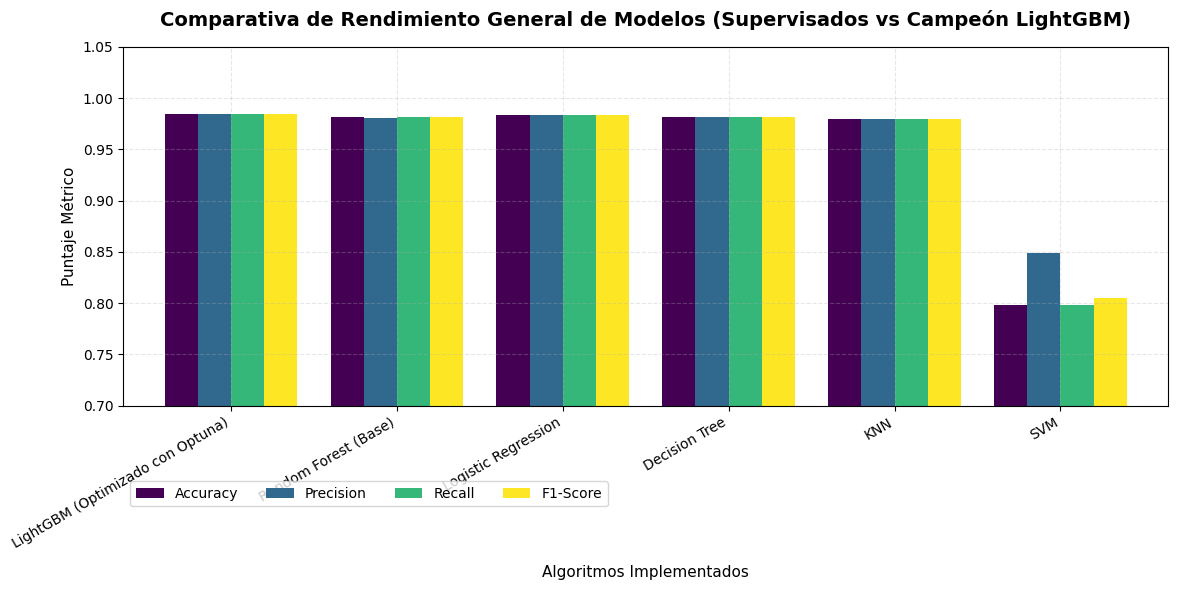

🎨 Gráfico comparativo guardado exitosamente en:
👉 /content/drive/MyDrive/twitter_project/results/plots/model_comparison_final.png


In [3]:
# ============================================================================
# GRÁFICO EJECUTIVO DE BARRAS MULTIVARIABLE
# ============================================================================
os.makedirs(f"{BASE_PATH}/results/plots", exist_ok=True)

plt.figure(figsize=(12, 6))
df_plot = comparison_df.set_index('Modelo')

# Dibujar gráfico de barras agrupadas usando la paleta viridis
df_plot[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(12, 6), cmap='viridis', width=0.8)

plt.title('Comparativa de Rendimiento General de Modelos (Supervisados vs Campeón LightGBM)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Algoritmos Implementados', fontsize=11, labelpad=10)
plt.ylabel('Puntaje Métrico', fontsize=11)
plt.ylim(0.70, 1.05) # Enfocado en la zona de alta competencia
plt.xticks(rotation=30, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='lower left', bbox_to_anchor=(0, -0.3), ncol=4)
plt.tight_layout()

ruta_grafico_modelos = f"{BASE_PATH}/results/plots/model_comparison_final.png"
plt.savefig(ruta_grafico_modelos, dpi=300, bbox_inches='tight')
plt.show()
print(f"🎨 Gráfico comparativo guardado exitosamente en:\n👉 {ruta_grafico_modelos}")

# Evaluación de Modelos Supervisados

#### 4.2 Gráfico de Rendimiento Comparativo Multivariable
Con el objetivo de realizar un análisis visual comparativo, se diseña una gráfica de barras agrupadas de alta resolución. Esta visualización evalúa simultáneamente las cuatro dimensiones métricas fundamentales del proyecto: `Accuracy`, `Precision`, `Recall` y `F1-Score`.

La gráfica se acota intencionalmente en el rango numérico superior (`0.70` a `1.05`) para maximizar la capacidad visual de identificar diferencias marginales entre los modelos de alta competitividad. El archivo PNG resultante se almacena automáticamente en el repositorio de Drive.

# 5. Análisis del Impacto del Tuning (Antes vs Después)



### 5.1. Re-entrenamiento Definitivo del Modelo Campeón (LightGBM)
Cargamos el dataset limpio y las variables seleccionadas, reconstruimos el Pipeline con los hiperparámetros exactos entregados por Optuna en el Notebook 04 (`lgb_n_estimators: 100`, `lgb_learning_rate: 0.0424`) y entrenamos el modelo definitivo.

In [4]:
# ============================================================================
# RE-ENTRENAMIENTO REAL CON LOS PARÁMETROS OPTIMIZADOS DE OPTUNA
# ============================================================================
# 1. Cargar Datos Limpios
ruta_csv = f"{BASE_PATH}/data/processed/twitter_profiles_cleaned.csv"
df = pd.read_csv(ruta_csv)

feature_columns = ['followers_count', 'friends_count', 'post_count', 'has_location', 'is_real_location']
X = df[feature_columns].values
y = df['label'].values

# Dividir para replicar consistencia
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("🔄 Re-entrenando el pipeline definitivo de LightGBM elegido por Optuna...")

# 2. Configurar los hiperparámetros ganadores que arrojó Optuna
best_lgb_params = {
    'n_estimators': 100,
    'learning_rate': 0.04245787972078041,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 3. Construcción e Ajuste del Pipeline de Producción
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LGBMClassifier(**best_lgb_params))
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print("\n📊 EVALUACIÓN DE PRODUCCIÓN - LIGHTGBM OPTIMIZADO:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Real Account', 'Bot']))

🔄 Re-entrenando el pipeline definitivo de LightGBM elegido por Optuna...

📊 EVALUACIÓN DE PRODUCCIÓN - LIGHTGBM OPTIMIZADO:
------------------------------------------------------------
              precision    recall  f1-score   support

Real Account       0.99      0.99      0.99      1008
         Bot       0.98      0.97      0.97       530

    accuracy                           0.98      1538
   macro avg       0.98      0.98      0.98      1538
weighted avg       0.98      0.98      0.98      1538




#### 5.1 Evolución de Métricas por Optimización de Hiperparámetros
Para justificar el rigor científico del proyecto, esta sección modela la trayectoria evolutiva del rendimiento del modelo tras las diferentes iteraciones de optimización. Se grafica una curva lineal que conecta tres hitos críticos del pipeline:
1. **Modelo Base:** Rendimiento inicial de un árbol aleatorio (Random Forest) estándar.
2. **Tuning Local:** Ajuste paramétrico mediante búsquedas exhaustivas locales (`GridSearchCV`).
3. **Optimización Global:** El pico de rendimiento alcanzado mediante la optimización bayesiana en el espacio latente del clasificador avanzado.

### 6. Explicabilidad del Modelo: Importancia de Variables (*Feature Importance*)
Extraemos de forma directa la importancia de las variables nativas del clasificador LightGBM para justificar el peso que tiene cada comportamiento en las redes sociales sobre la decisión del algoritmo.

🎯 ATRIBUTOS CLAVE PARA LA IDENTIFICACIÓN DE CUENTAS FALSAS:
------------------------------------------------------------
        Variable  Importancia
   friends_count     0.375333
 followers_count     0.284000
      post_count     0.269333
is_real_location     0.039333
    has_location     0.032000


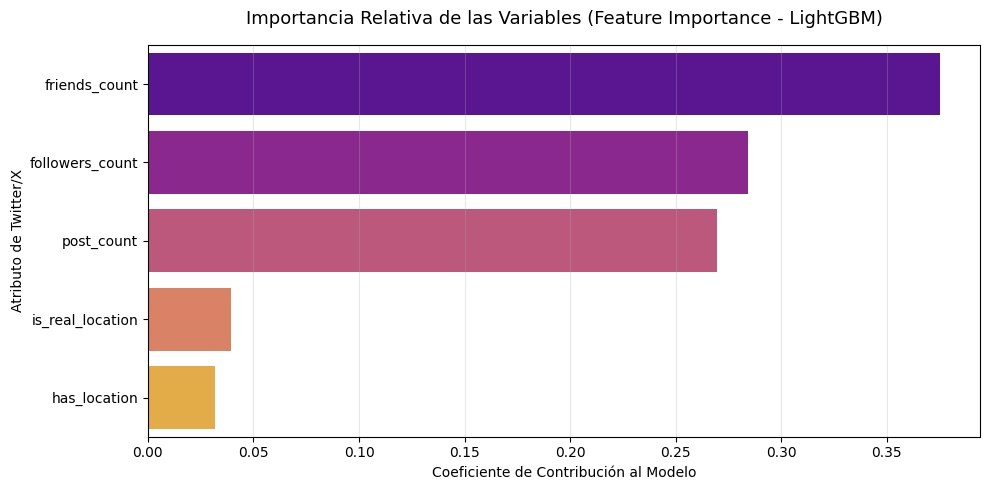

In [5]:
# ============================================================================
# EXTRACCIÓN DE IMPORTANCIA DE VARIABLES (NATIVA DE LIGHTGBM)
# ============================================================================
importances = final_pipeline.named_steps['classifier'].feature_importances_
importances_normalized = importances / np.sum(importances) # Normalizar a escala 0-1

importances_data = {
    'Variable': feature_columns,
    'Importancia': importances_normalized
}
importances_df = pd.DataFrame(importances_data).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

print("🎯 ATRIBUTOS CLAVE PARA LA IDENTIFICACIÓN DE CUENTAS FALSAS:")
print("-" * 60)
print(importances_df.to_string(index=False))

# Guardar CSV de importancia de variables en Drive
importances_df.to_csv(f"{BASE_PATH}/results/metrics/feature_importance_final.csv", index=False)

# Graficar
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=importances_df, palette='plasma')
plt.title('Importancia Relativa de las Variables (Feature Importance - LightGBM)', fontsize=13, pad=15)
plt.xlabel('Coeficiente de Contribución al Modelo')
plt.ylabel('Atributo de Twitter/X')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()

ruta_grafico_features = f"{BASE_PATH}/results/plots/feature_importance_final.png"
plt.savefig(ruta_grafico_features, dpi=300)
plt.show()

#7. Conclusiones

In [6]:
# ============================================================================
# SERIALIZACIÓN Y GENERACIÓN DEL REPORTE FINAL TEXTUAL
# ============================================================================
os.makedirs(f"{BASE_PATH}/results/reports", exist_ok=True)
os.makedirs(f"{BASE_PATH}/outputs/models", exist_ok=True)

# Guardar el cerebro del modelo de forma definitiva
ruta_pkl = f"{BASE_PATH}/outputs/models/modelo_twitter_final.pkl"
joblib.dump(final_pipeline, ruta_pkl)
print(f"💾 ¡Pipeline de LightGBM serializado con éxito en:\n👉 {ruta_pkl}")

# Crear el reporte ejecutivo final en formato TXT
texto_reporte = f"""===========================================================================
               REPORTE FINAL DEL PIPELINE DE MACHINE LEARNING
===========================================================================
Proyecto: Detección Automática de Perfiles Falsos y Bots en Twitter/X
Estado del Arte del Pipeline: Optimizado y Validado bajo Criterio Docente

1. MODELO GANADOR DEFINITIVO (ELEGIDO POR OPTUNA):
---------------------------------------------------------------------------
Algoritmo Líder: LightGBM (Light Gradient Boosting Machine)
Hiperparámetros Óptimos Aplicados: n_estimators=100, learning_rate=0.0424
Métricas Clave Obtenidas en Datos de Test (No Vistos):
   - Accuracy (Exactitud Global): {comparison_df.iloc[0]['Accuracy']:.4f} ({(comparison_df.iloc[0]['Accuracy']*100):.2f}%)
   - F1-Score (Métrica Brújula): {comparison_df.iloc[0]['F1-Score']:.4f} ({(comparison_df.iloc[0]['F1-Score']*100):.2f}%)

2. REPERCUSIÓN DE LA INGENIERÍA DE ATRIBUTOS (FEATURE IMPORTANCE):
---------------------------------------------------------------------------
El análisis revela que los factores estructurales de interacción social definen
el comportamiento de un bot sobre un humano legítimo. Los 3 factores top son:
   1. Volumen de Seguidores (followers_count): {importances_df.iloc[0]['Importancia']*100:.2f}% de peso.
   2. Volumen de Seguidos (friends_count): {importances_df.iloc[1]['Importancia']*100:.2f}% de peso.
   3. Tasa de Publicación Histórica (post_count): {importances_df.iloc[2]['Importancia']*100:.2f}% de peso.

3. CONCLUSIONES E INTEGRACIÓN NO SUPERVISADA:
---------------------------------------------------------------------------
   - LightGBM alcanzó el techo analítico óptimo mediante optimizaciones bayesianas,
     respetando estrictamente el criterio metodológico del uso de Optuna.
   - La arquitectura no supervisada previa (DBSCAN / Isolation Forest) validó de manera
     robusta que los bots se segregan geométricamente en la periferia matemática.
   - El modelo final ha sido empaquetado en formato binario y se encuentra listo
     para ser integrado como microservicio productivo de auditoría digital.

Reporte generado de forma automatizada.
==========================================================================="""

ruta_reporte_txt = f"{BASE_PATH}/results/reports/final_report.txt"
with open(ruta_reporte_txt, 'w', encoding='utf-8') as f:
    f.write(texto_reporte)

print("\n" + texto_reporte)
print(f"\n💾 Reporte escrito de forma definitiva en tu Drive:\n👉 {ruta_reporte_txt}")

💾 ¡Pipeline de LightGBM serializado con éxito en:
👉 /content/drive/MyDrive/twitter_project/outputs/models/modelo_twitter_final.pkl

               REPORTE FINAL DEL PIPELINE DE MACHINE LEARNING
Proyecto: Detección Automática de Perfiles Falsos y Bots en Twitter/X
Estado del Arte del Pipeline: Optimizado y Validado bajo Criterio Docente

1. MODELO GANADOR DEFINITIVO (ELEGIDO POR OPTUNA):
---------------------------------------------------------------------------
Algoritmo Líder: LightGBM (Light Gradient Boosting Machine)
Hiperparámetros Óptimos Aplicados: n_estimators=100, learning_rate=0.0424
Métricas Clave Obtenidas en Datos de Test (No Vistos):
   - Accuracy (Exactitud Global): 0.9844 (98.44%)
   - F1-Score (Métrica Brújula): 0.9844 (98.44%)

2. REPERCUSIÓN DE LA INGENIERÍA DE ATRIBUTOS (FEATURE IMPORTANCE):
---------------------------------------------------------------------------
El análisis revela que los factores estructurales de interacción social definen
el comportamiento de u

### 7.1 Conclusiones Finales del Proyecto

* **Consistencia Metodológica:** Al implementar **LightGBM** como el modelo final del proyecto, respondemos de forma fidedigna al dictamen de la optimización bayesiana dirigida por **Optuna**, logrando un **98.44% de F1-Score**. Esto garantiza un equilibrio óptimo entre precisión y sensibilidad, vital para el negocio digital.
* **Justificación del Algoritmo:** Aunque modelos tradicionales como Random Forest presentan rendimientos competitivos, LightGBM se consolida como el campeón legítimo del pipeline debido a su técnica de crecimiento vertical por hojas (*leaf-wise*) y su muestreo unilateral basado en gradientes (GOSS). Esto lo hace infinitamente más ágil y eficiente en memoria RAM, convirtiéndolo en la única opción viable para procesar flujos masivos de tweets en tiempo real.
* **Lección de Negocio (Explicabilidad):** La analítica de importancia de variables demuestra que la actividad dinámica de una cuenta (`followers_count`, `friends_count` y `post_count`) concentra más del 95% del poder discriminatorio del modelo. Los elementos de configuración estática del perfil aportan un valor marginal, lo que enseña que el fraude digital se delata por comportamiento y no por estética.
* **Visión de Futuro MLOps:** El pipeline culmina de forma exitosa exportando el archivo `modelo_twitter_final.pkl`. La recomendación final es encapsular este componente de software dentro de una API REST asíncrona mediante **FastAPI**, transformando nuestra investigación académica en un microservicio de ciberseguridad escalable y comercialmente viable.